In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# Load pre-trained MobileNetV3 model
base_model = MobileNetV3Small(input_shape=(224, 224, 3), include_top=False, weights='imagenet')


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 1us/step


In [3]:
# Add custom layers for PAR
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(26, activation='sigmoid')(x)  # PA-100K has 26 attributes

In [4]:
# Create the model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [7]:
import pandas as pd

In [8]:
# Define paths
train_csv_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/train.csv'
val_csv_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/val.csv'
test_csv_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/test.csv'
image_dir = 'PA-100K/data'

# Load annotations
train_annotations = pd.read_csv(train_csv_path)
val_annotations = pd.read_csv(val_csv_path)
test_annotations = pd.read_csv(test_csv_path)

# Define image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Create data generators with augmentation
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20, width_shift_range=0.2, height_shift_range=0.2)
val_test_datagen = ImageDataGenerator(rescale=1./255)

def create_generator(datagen, annotations, image_dir):
    generator = datagen.flow_from_dataframe(
        dataframe=annotations,
        directory=image_dir,
        x_col='Image',  # Correct column name for image IDs
        y_col=annotations.columns[1:],
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='raw'
    )
    return generator

train_generator = create_generator(train_datagen, train_annotations, image_dir)
val_generator = create_generator(val_test_datagen, val_annotations, image_dir)
test_generator = create_generator(val_test_datagen, test_annotations, image_dir)


Found 80000 validated image filenames.
Found 10000 validated image filenames.
Found 10000 validated image filenames.


In [9]:
# Train the model
history = model.fit(train_generator, epochs=10, steps_per_epoch=100, validation_data=val_generator, validation_steps=50)

/opt/homebrew/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 198ms/step - accuracy: 0.4478 - loss: 0.4148 - val_accuracy: 0.4256 - val_loss: 0.3955
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 196ms/step - accuracy: 0.5017 - loss: 0.3710 - val_accuracy: 0.4325 - val_loss: 0.3861
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.5214 - loss: 0.3701 - val_accuracy: 0.4181 - val_loss: 0.3897
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - accuracy: 0.5027 - loss: 0.3648 - val_accuracy: 0.4225 - val_loss: 0.3912
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 191ms/step - accuracy: 0.4845 - loss: 0.3660 - val_accuracy: 0.4275 - val_loss: 0.3837
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.5202 - loss: 0.3622 - val_accuracy: 0.4238 - val_loss: 0.3830
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.5088 - loss: 0.3606 - val_accuracy: 0.4700 - val_loss: 0.3747
Epoch 8/10
  1/100 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.5625 - loss: 0.3

2025-02-10 01:22:49.792189: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/opt/homebrew/Cellar/python@3.11/3.11.6_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.4998 - loss: 0.3648 - val_accuracy: 0.4412 - val_loss: 0.3855
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step - accuracy: 0.5176 - loss: 0.3641 - val_accuracy: 0.4238 - val_loss: 0.3831
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 188ms/step - accuracy: 0.4875 - loss: 0.3700 - val_accuracy: 0.4319 - val_loss: 0.3863


In [10]:
# Fine-tune the model
for layer in base_model.layers:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

history_fine = model.fit(train_generator, epochs=10, steps_per_epoch=100, validation_data=val_generator, validation_steps=50)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 517ms/step - accuracy: 0.4907 - loss: 0.5077 - val_accuracy: 0.4350 - val_loss: 0.3895
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 484ms/step - accuracy: 0.4709 - loss: 0.4344 - val_accuracy: 0.4306 - val_loss: 0.3881
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 485ms/step - accuracy: 0.4681 - loss: 0.4090 - val_accuracy: 0.4325 - val_loss: 0.3933
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 454ms/step - accuracy: 0.4750 - loss: 0.3963 - val_accuracy: 0.4425 - val_loss: 0.3999
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 493ms/step - accuracy: 0.4715 - loss: 0.3913 - val_accuracy: 0.4325 - val_loss: 0.4071
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 488ms/step - accuracy: 0.4564 - loss: 0.3840 - val_accuracy: 0.4475 - val_loss: 0.4161
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 43s 429ms/step - accuracy: 0.4836 - loss: 0.3808 - val_accuracy: 0.4375 - val_loss: 0.4272
Epoch 8/10


2025-02-10 01:29:40.666793: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 458ms/step - accuracy: 0.4814 - loss: 0.3736 - val_accuracy: 0.4356 - val_loss: 0.4292
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 460ms/step - accuracy: 0.4743 - loss: 0.3689 - val_accuracy: 0.4144 - val_loss: 0.4275
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 46s 462ms/step - accuracy: 0.4935 - loss: 0.3668 - val_accuracy: 0.4444 - val_loss: 0.4209


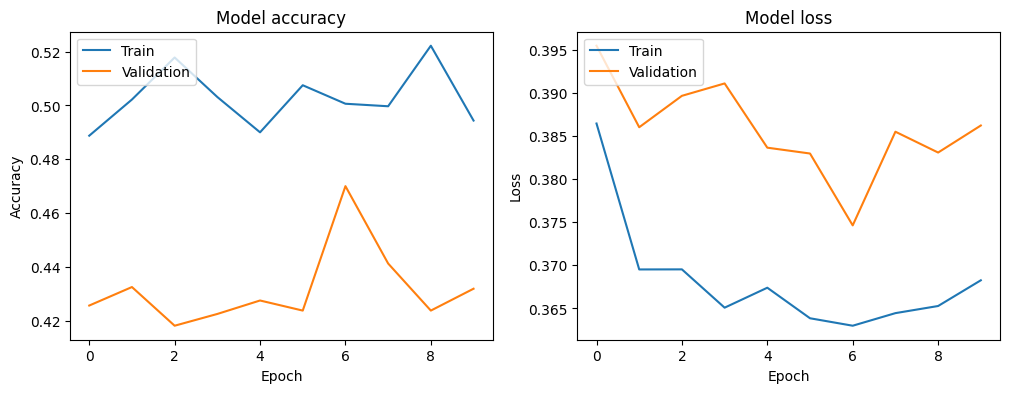

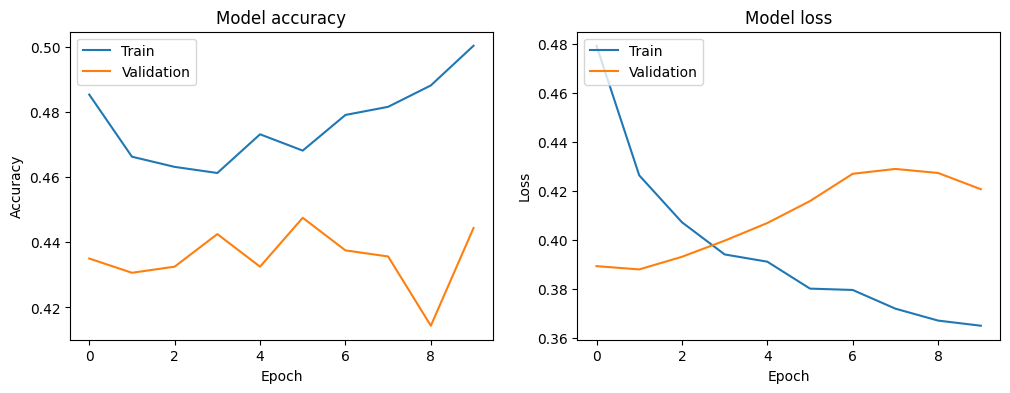

In [11]:
# Plot training & validation accuracy and loss curves
def plot_training_curves(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

plot_training_curves(history)
plot_training_curves(history_fine)

In [12]:
# Generate confusion matrices and classification report for validation and test data
def generate_confusion_matrices(generator, model, num_attributes):
    generator.reset()
    predictions = model.predict(generator, steps=len(generator))
    predictions = (predictions > 0.5).astype(int)  # Threshold predictions

    true_labels = []
    for i in range(len(generator)):
        true_labels.append(generator[i][1])
    true_labels = np.array(true_labels)

    for i in range(num_attributes):
        cm = confusion_matrix(true_labels[:, i], predictions[:, i])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix for Attribute {i}')
        plt.show()

    report = classification_report(true_labels, predictions, target_names=[f'Attribute {i}' for i in range(num_attributes)])
    print(report)

num_attributes = 26

print("Validation Data:")
generate_confusion_matrices(val_generator, model, num_attributes)

print("Test Data:")
generate_confusion_matrices(test_generator, model, num_attributes)

Validation Data:
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 83ms/step


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (313,) + inhomogeneous part.

313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 81ms/step


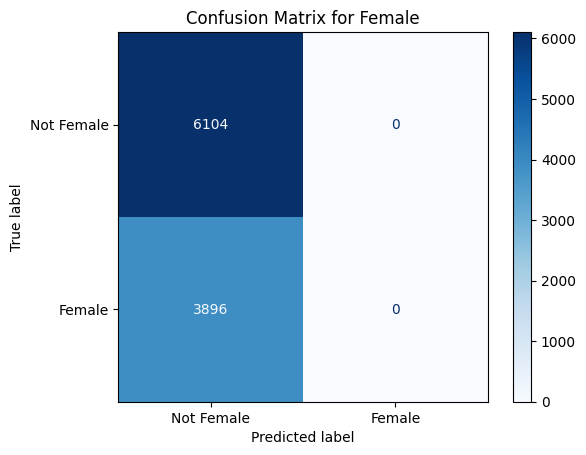

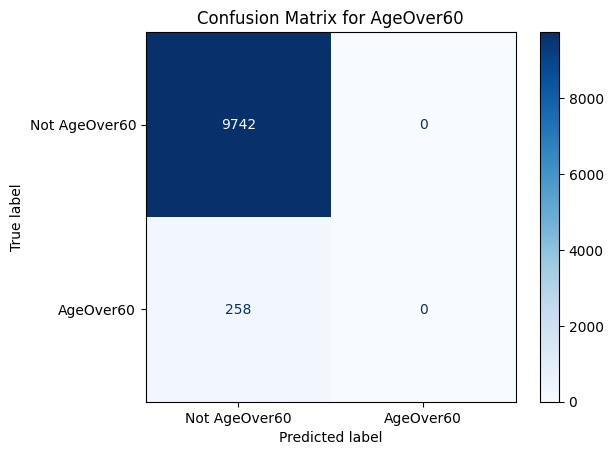

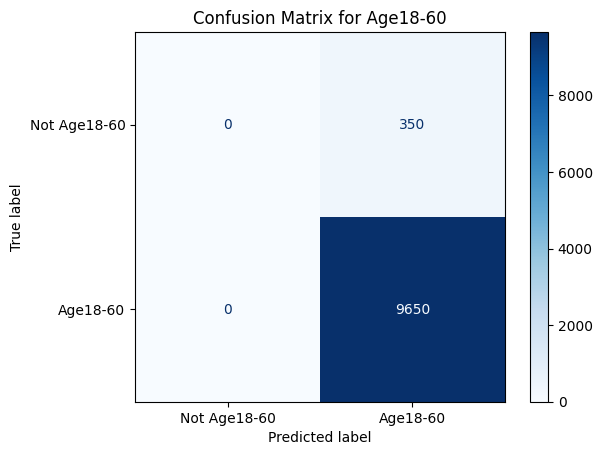

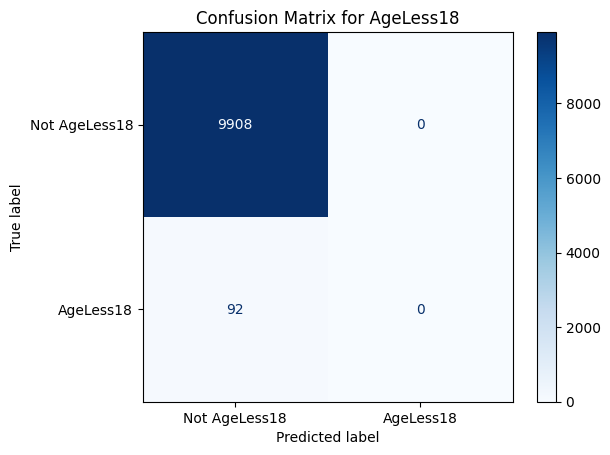

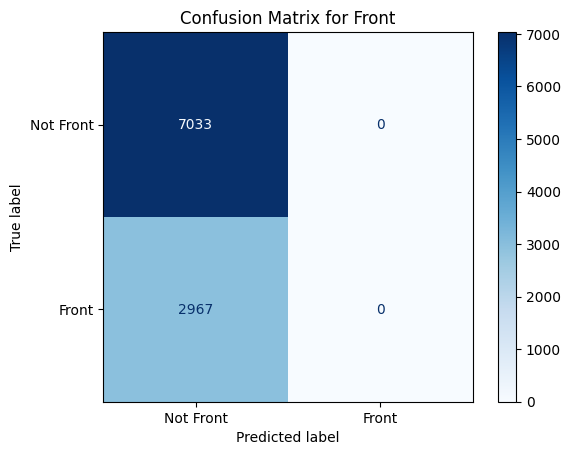

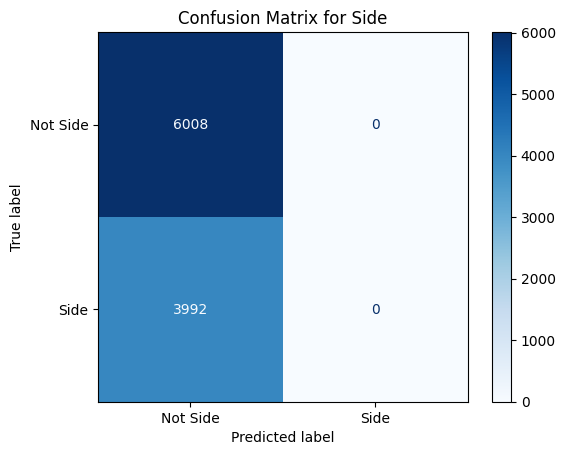

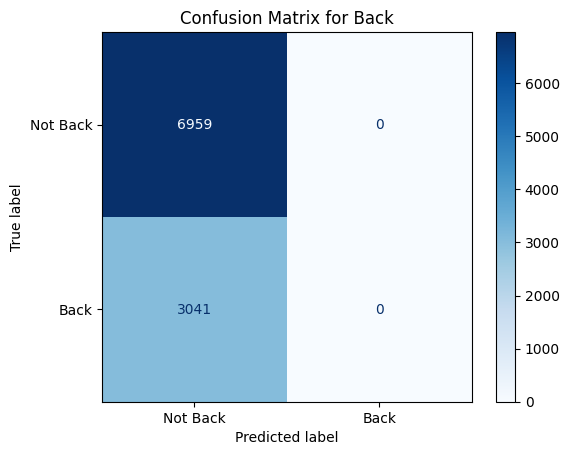

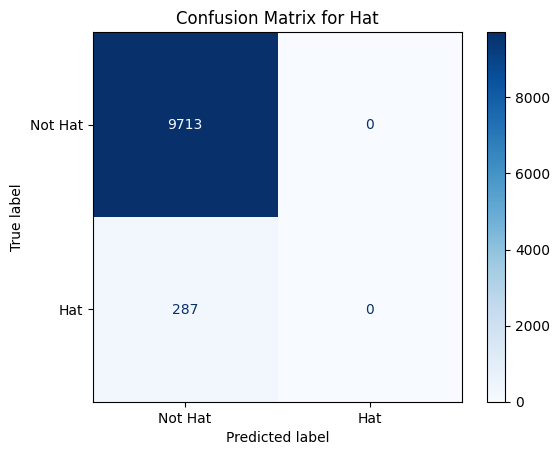

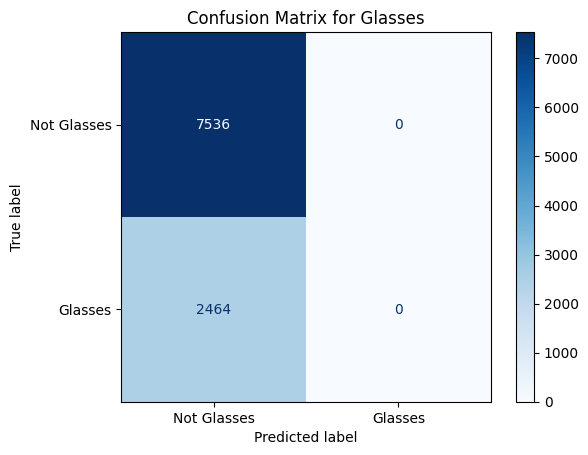

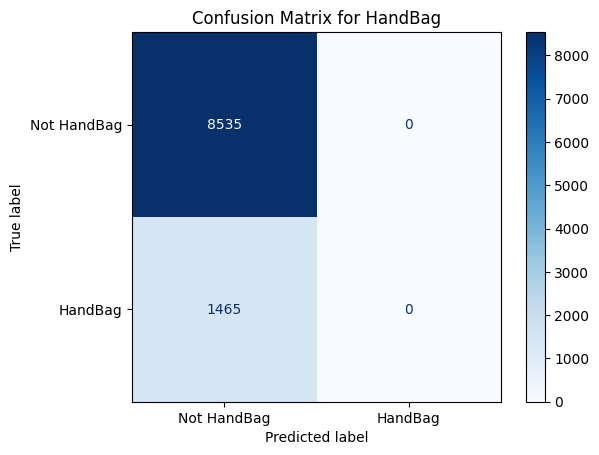

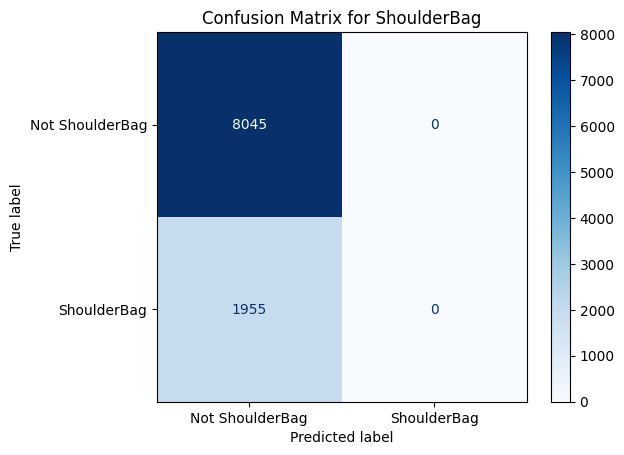

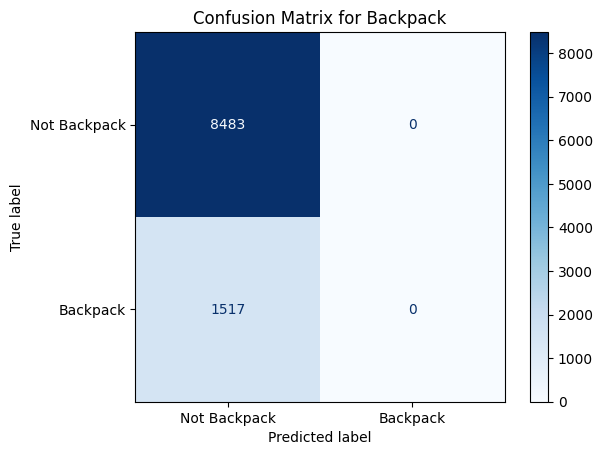

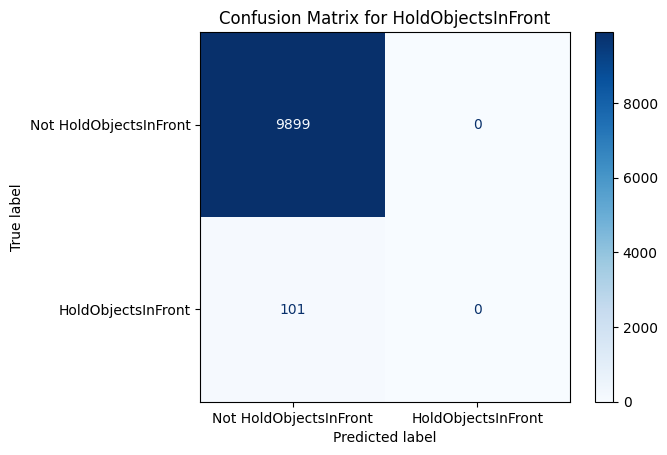

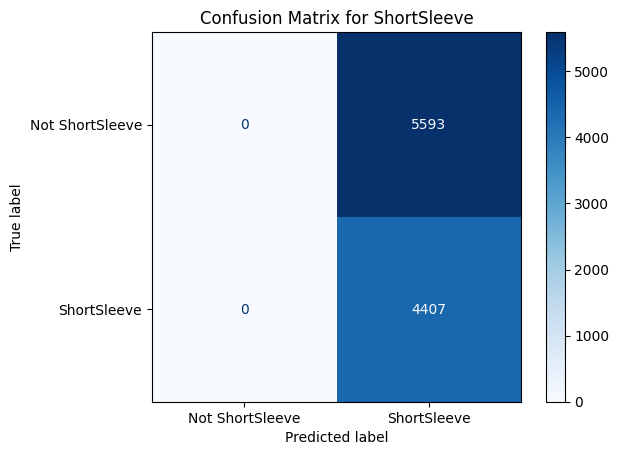

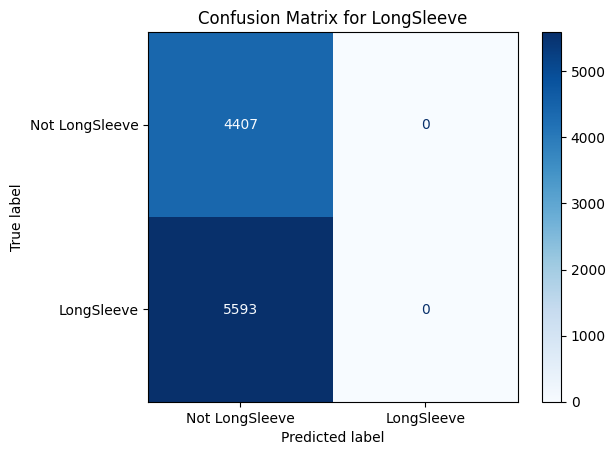

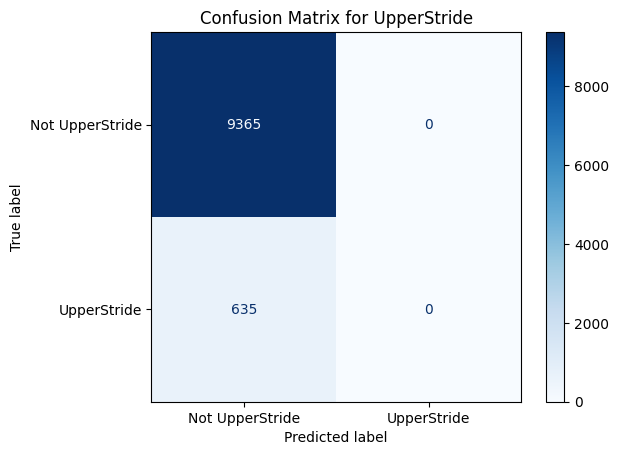

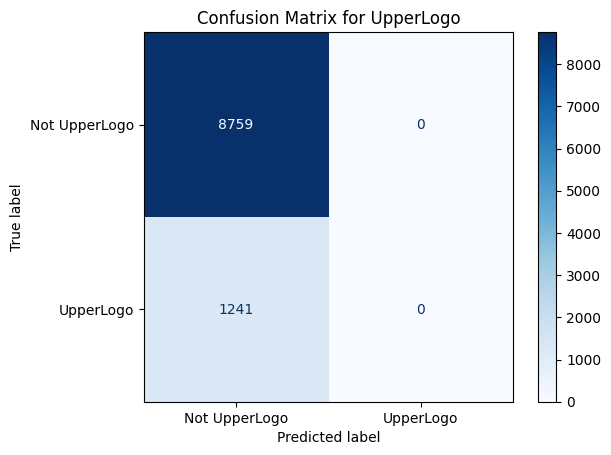

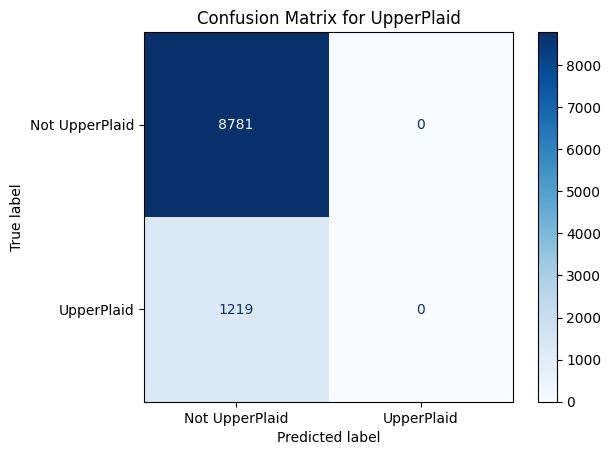

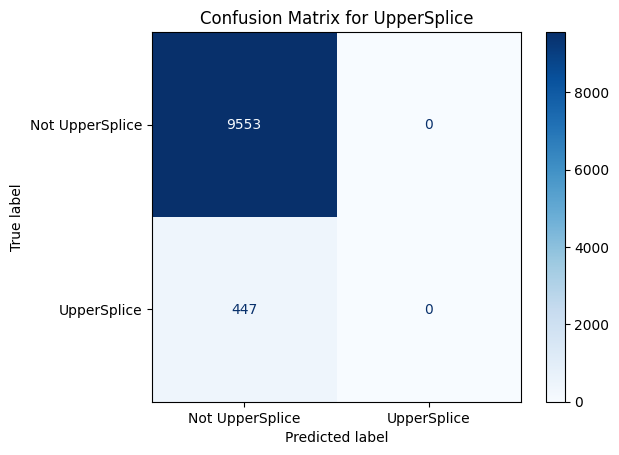

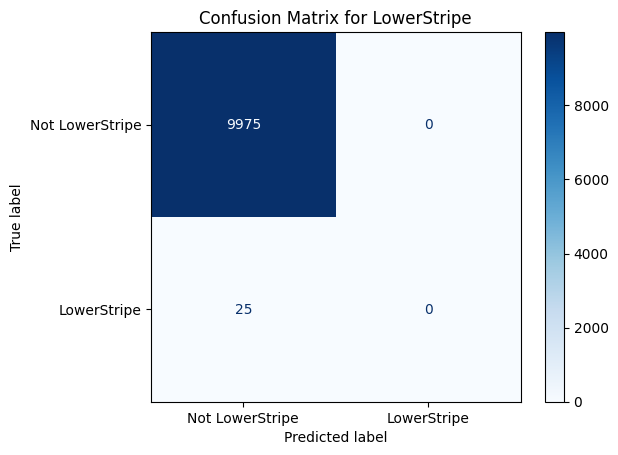

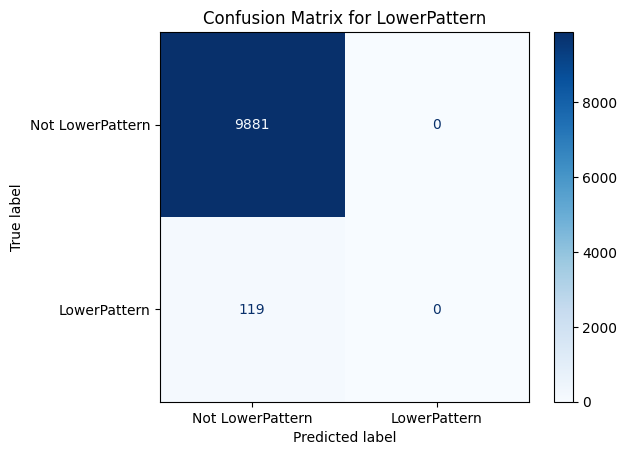

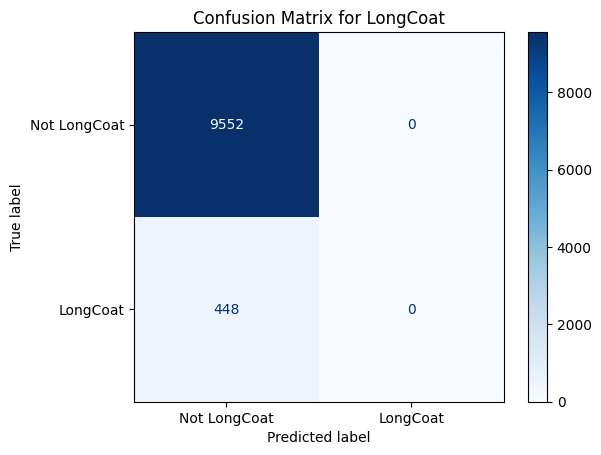

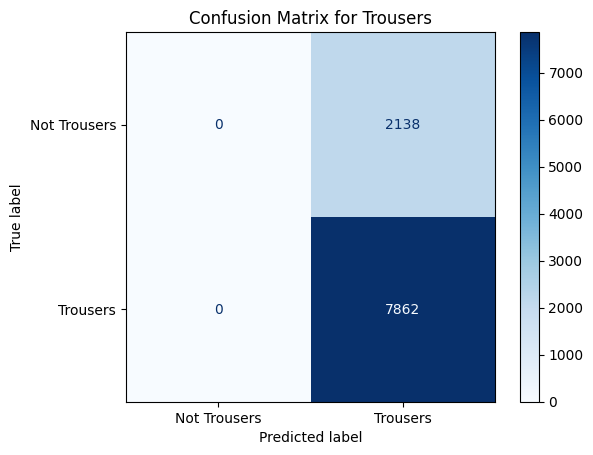

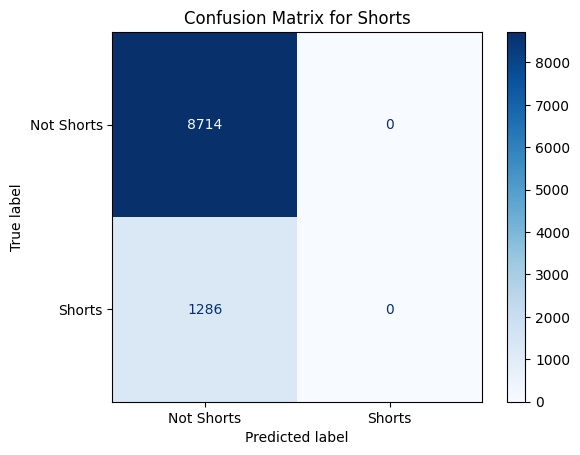

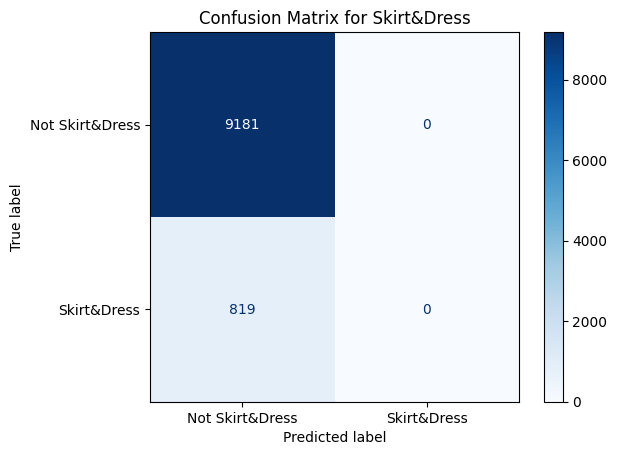

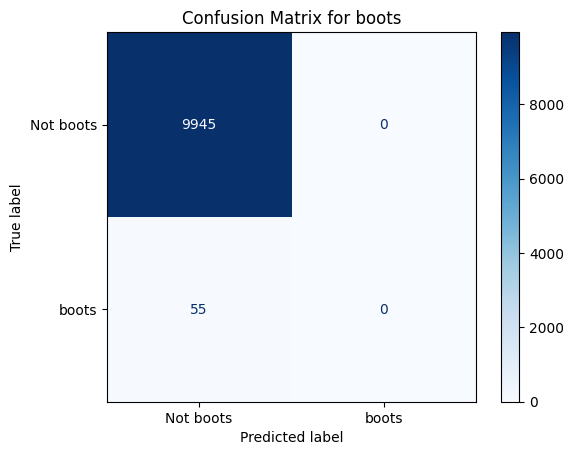

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Make predictions on the test set
test_predictions = model.predict(test_generator)
test_predictions = (test_predictions > 0.5).astype(int)  # Threshold predictions

# Get true labels
true_labels = test_annotations.drop(columns=['Image']).values

# Plot confusion matrix for each attribute
for i, attribute in enumerate(train_annotations.columns[1:]):
    cm = confusion_matrix(true_labels[:, i], test_predictions[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not ' + attribute, attribute])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix for {attribute}')
    plt.show()


In [15]:
# Function to predict attributes from a single image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import matplotlib.pyplot as plt
import numpy as np

def predict_image(image_path, model):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predictions = (predictions > 0.5).astype(int)  # Threshold predictions

    attribute_labels = [f'Attribute {i}' for i in range(num_attributes)]
    predicted_labels = [attribute_labels[i] for i in range(len(predictions[0])) if predictions[0][i] == 1]

    print("Predicted Attributes:")
    for label in predicted_labels:
        print(label)

# Example usage
image_path = '/Users/sanchitthakur/Desktop/real_major/PA-100K/data/000010.jpg'
predict_image(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
Predicted Attributes:
Attribute 2
Attribute 13
Attribute 22


In [16]:
model.save('mobilenetv3_model.h5')